**CAMB Python example notebook**

Run it online yourself in [Binder](https://mybinder.org/v2/gh/cmbant/camb/master?filepath=docs%2FCAMBdemo.ipynb).

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import camb
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
from camb import model, initialpower
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))
# make sure the version and path is what you expect

Using CAMB 1.5.8 installed at /Users/zhouxue/Desktop/WMG/code/WMGCAMB/camb


In [3]:
#Set up a new set of parameters for CAMB
#The defaults give one massive neutrino and helium set using BBN consistency
lcdmcosmology = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,M=0,N=0,
                       As=2e-9, ns=0.965, halofit_version='mead', WantTransfer=True)
lcdmresults = camb.get_results(lcdmcosmology)
lcdmcls = lcdmresults.get_unlensed_scalar_cls(CMB_unit = 'muK')[:,0]
lcdmks = lcdmresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[0]
lcdmpks = lcdmresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[2]
lcdmpowers =lcdmresults.get_cmb_power_spectra(lcdmcosmology, CMB_unit='muK')


[ 67.5         67.51609118  67.53219462 ... 121.1174993  121.1533365
 121.18918103]
[0.00000000e+00 5.00250125e-04 1.00050025e-03 ... 9.98999500e-01
 9.99499750e-01 1.00000000e+00]
[ 67.5         67.51404415  67.52810021 ... 117.68875448 117.72344655
 117.7581465 ]
[0.00000000e+00 5.00250125e-04 1.00050025e-03 ... 9.98999500e-01
 9.99499750e-01 1.00000000e+00]
[67.5        67.50380805 67.50762444 ... 98.77557592 98.80386878
 98.83217295]
[0.00000000e+00 5.00250125e-04 1.00050025e-03 ... 9.98999500e-01
 9.99499750e-01 1.00000000e+00]
[ 67.5         67.52018506  67.5403827  ... 127.69909965 127.73712498
 127.77515667]
[0.00000000e+00 5.00250125e-04 1.00050025e-03 ... 9.98999500e-01
 9.99499750e-01 1.00000000e+00]


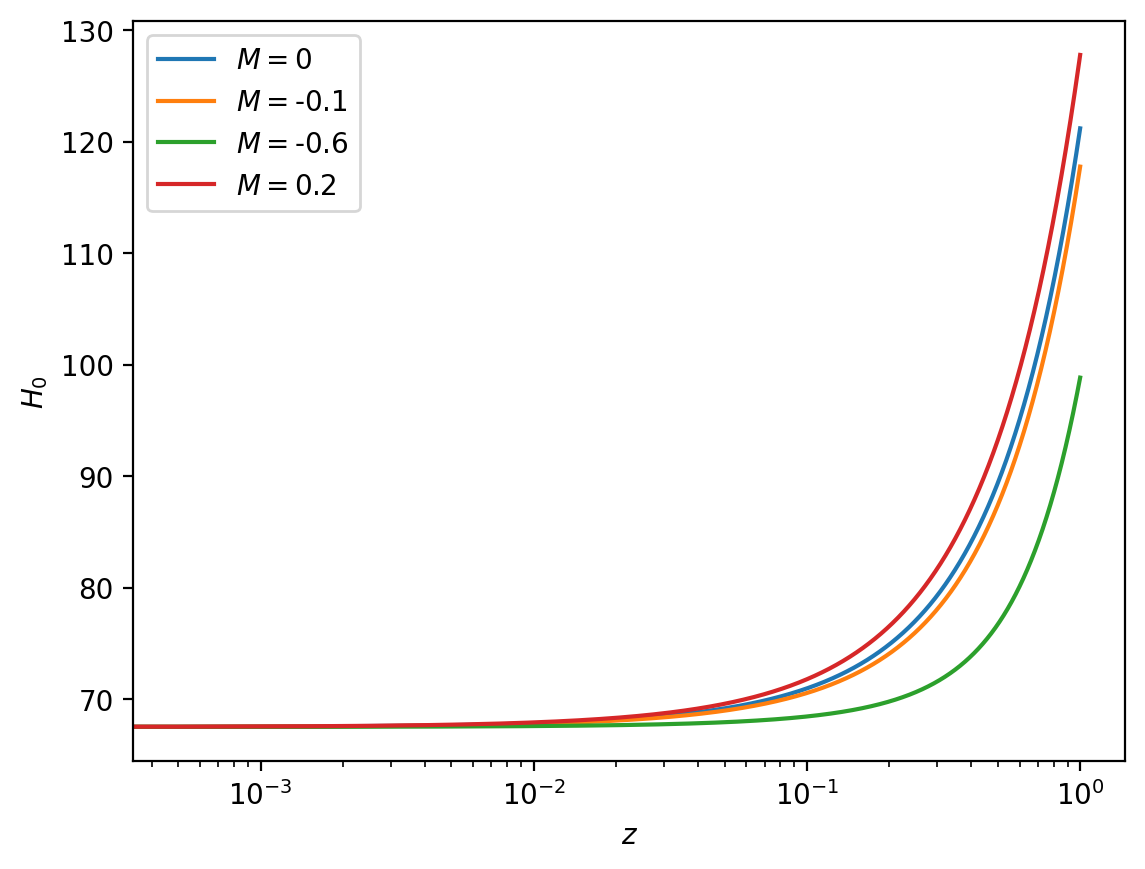

In [4]:
Ms = [0, -0.1,-0.6,0.2]
legends = [r'$M = $'+ str(x) for x in Ms]
for M in Ms:
    
    gpncosmology=camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,M=M,N=0.3,
                       As=2e-9, ns=0.965, halofit_version='mead', WantTransfer=True)
    gpnresults = camb.get_results(gpncosmology)
    gpncls = gpnresults.get_unlensed_scalar_cls(CMB_unit = 'muK')[:,0]
    gpnks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[0]
    gpnpks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[2]
    gpnpowers =gpnresults.get_cmb_power_spectra(gpncosmology, CMB_unit='muK')
    scales = np.array(np.linspace(10**(-4), 1, 20000))
    z = np.array(np.linspace(0, 1, 2000))
    omegaphis = gpnresults.hubble_parameter( z)
    redshifts = 1/scales - 1
    print(omegaphis)
    print(z)
    plt.plot(z, omegaphis)

plt.xscale('log')
#plt.xlim([10**1, 10**3])
#plt.ylim([0, 1250])
#plt.title('Hubble（z）')
plt.xlabel(r'$z$')
plt.ylabel(r'$H_0$')
plt.legend(legends)
#plt.grid()
plt.savefig('rocknroll_5_omegaphis.pdf')
plt.show()

[5.53022167e-13 3.14579468e-10 2.27565709e-09 ... 6.81804855e-01
 6.82130589e-01 6.82455981e-01]
[9.99900000e+03 1.66511102e+03 9.07760285e+02 ... 1.00140200e-03
 5.00450425e-04 0.00000000e+00]
[-1.80037277e-07 -4.29360296e-06 -1.15464720e-05 ...  6.81757893e-01
  6.82107139e-01  6.82455981e-01]
[9.99900000e+03 1.66511102e+03 9.07760285e+02 ... 1.00140200e-03
 5.00450425e-04 0.00000000e+00]
[-1.08022740e-06 -2.57637438e-05 -6.92942118e-05 ...  6.81522874e-01
  6.81989838e-01  6.82455981e-01]
[9.99900000e+03 1.66511102e+03 9.07760285e+02 ... 1.00140200e-03
 5.00450425e-04 0.00000000e+00]
[3.60076018e-07 8.58803902e-06 2.30989708e-05 ... 6.81898738e-01
 6.82177478e-01 6.82455981e-01]
[9.99900000e+03 1.66511102e+03 9.07760285e+02 ... 1.00140200e-03
 5.00450425e-04 0.00000000e+00]


/var/folders/t8/n3t6kl3x2pd9bnz701cp72q40000gn/T/ipykernel_84014/2744700689.py:22: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0, 10**6])


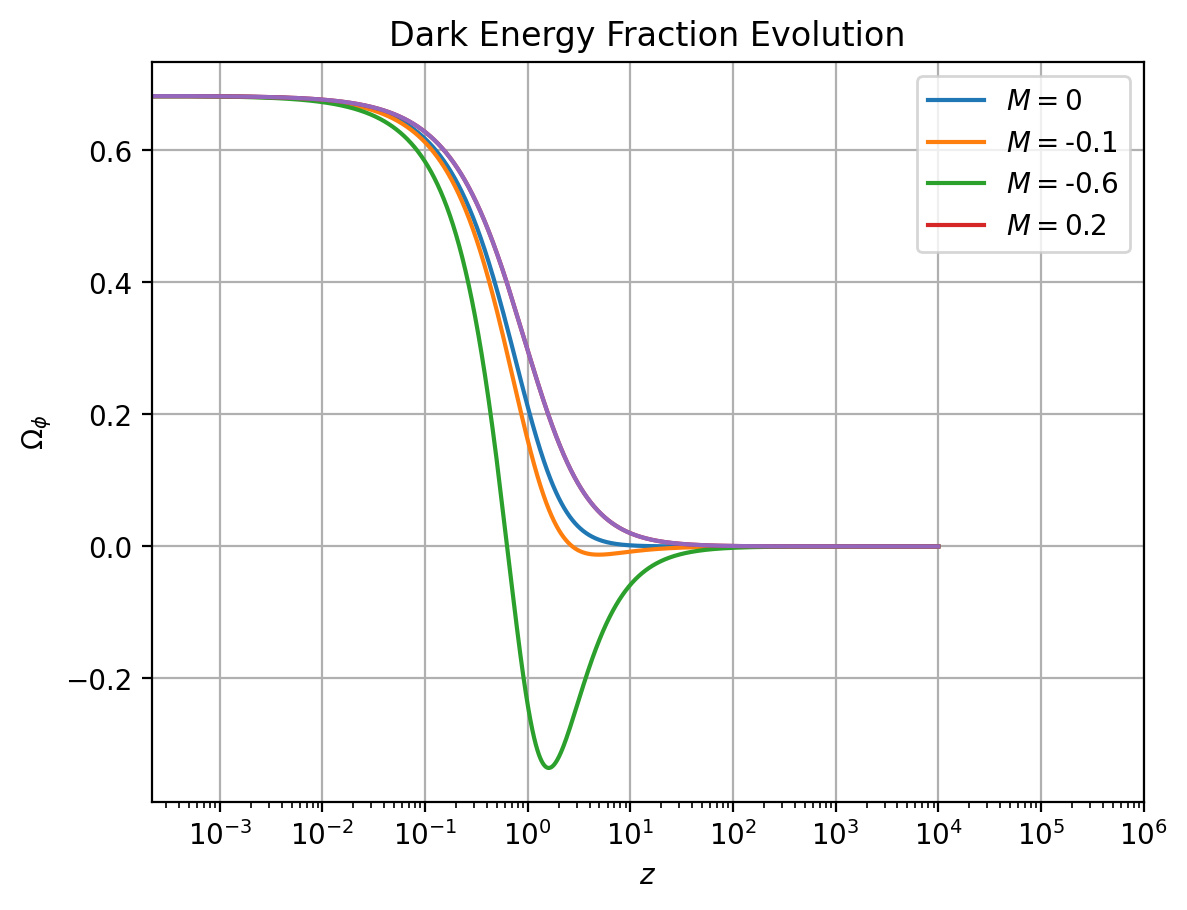

In [5]:
Ms = [0, -0.1,-0.6,0.2]
legends = [r'$M = $'+ str(x) for x in Ms]
for M in Ms:
    
    gpncosmology=camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,M=M,N=0.1,
                       As=2e-9, ns=0.965, halofit_version='mead', WantTransfer=True)
    gpnresults = camb.get_results(gpncosmology)
    gpncls = gpnresults.get_unlensed_scalar_cls(CMB_unit = 'muK')[:,0]
    gpnks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[0]
    gpnpks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[2]
    gpnpowers =gpnresults.get_cmb_power_spectra(gpncosmology, CMB_unit='muK')
    scales = np.array(np.linspace(10**(-4), 1, 2000))
    omegaphis = gpnresults.get_Omega('de', z = 1/scales - 1)
    omegaphis = gpnresults.get_Omega('de', z = 1/scales - 1)
    redshifts = 1/scales - 1
    print(omegaphis)
    print(redshifts)
    plt.plot(redshifts, omegaphis)

plt.plot(redshifts,omegaphis)
plt.xscale('log')
plt.xlim([0, 10**6])
plt.title('Dark Energy Fraction Evolution')
plt.xlabel(r'$z$')
plt.ylabel(r'$\Omega_\phi$')
plt.legend(legends)
plt.grid()
plt.savefig('rocknroll_5_omegaphis.pdf')
plt.show()

For further details of camb.symbolic and examples of what can be done see the [CAMB symbolic ScalEqs notebook](https://camb.readthedocs.io/en/latest/ScalEqs.html) (run now in [Binder](https://mybinder.org/v2/gh/cmbant/camb/master?filepath=docs%2FScalEqs.ipynb)). This also serves as documentation for the scalar equations implemented in CAMB.

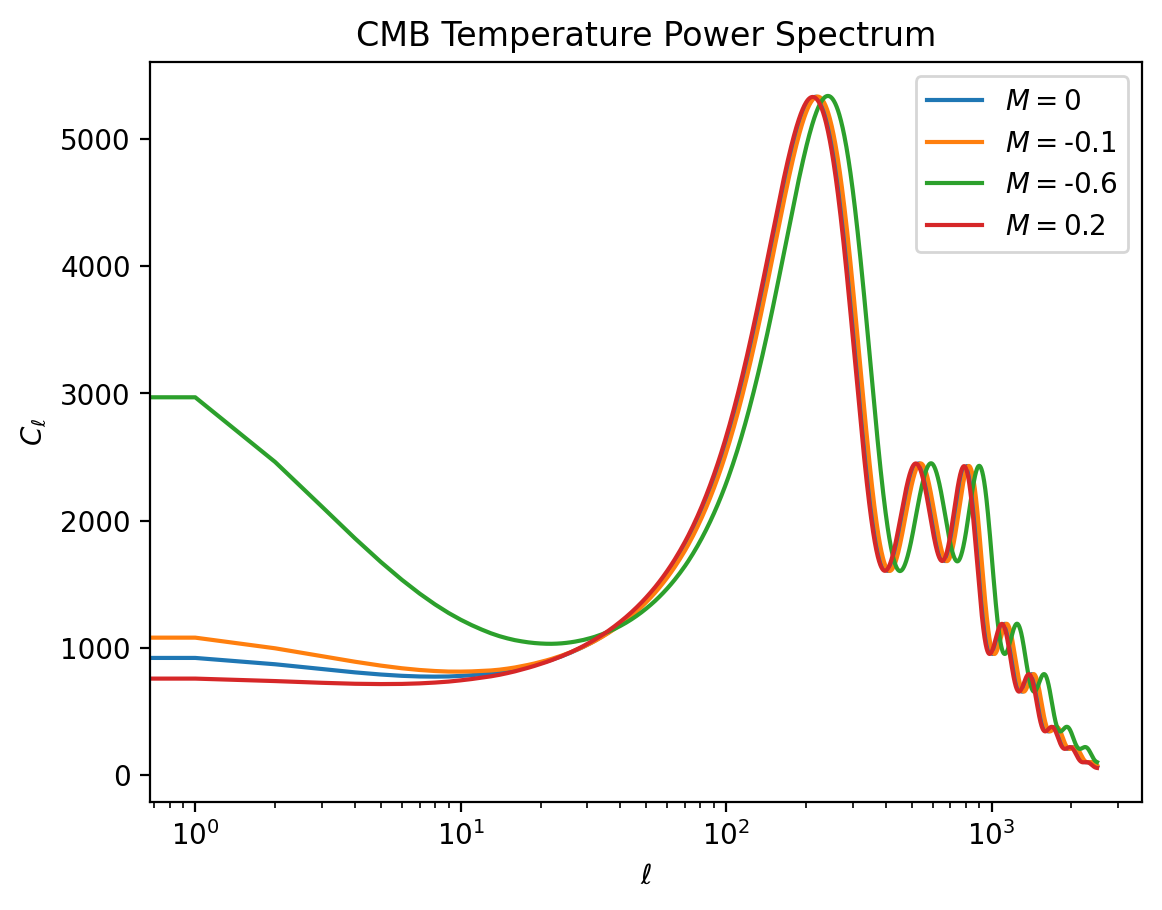

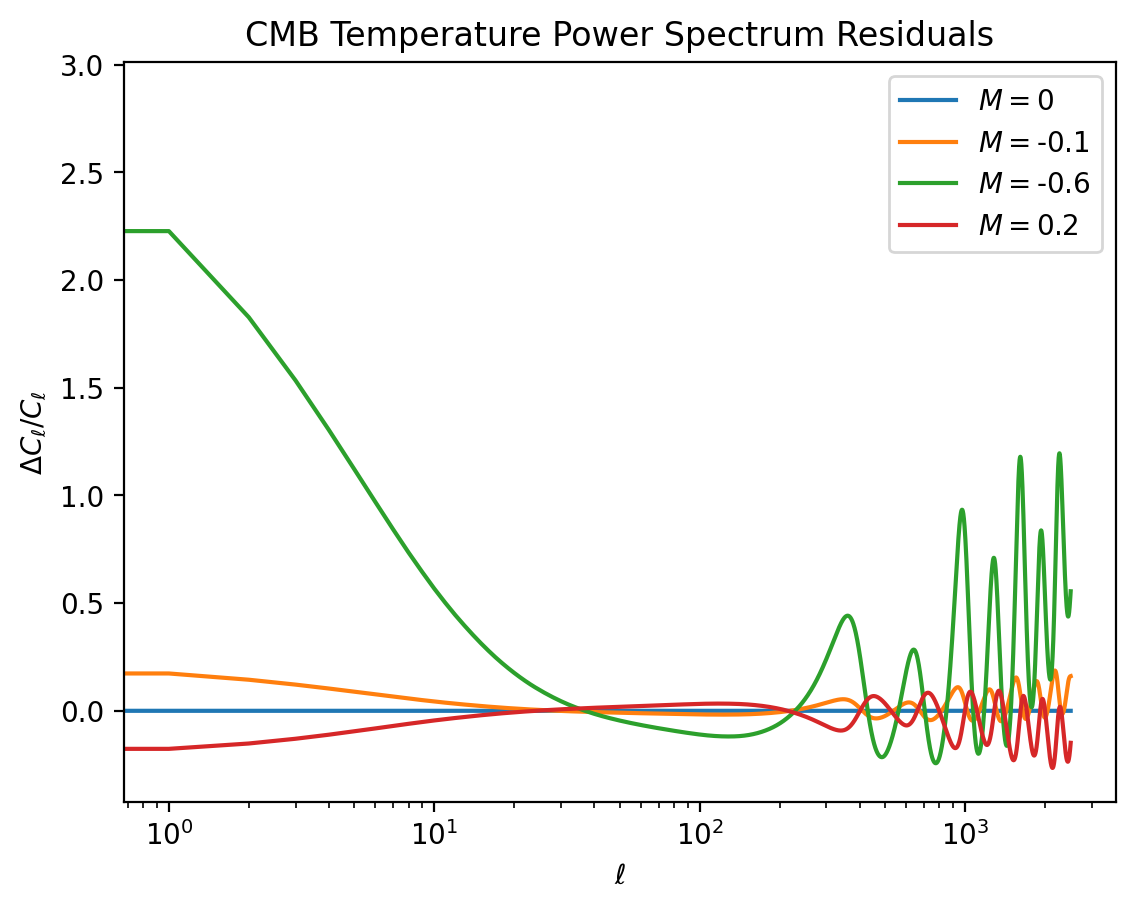

In [7]:
Ms = [0, -0.1,-0.6,0.2]
legends = [r'$M = $'+ str(x) for x in Ms]
for M in Ms:
    
    gpncosmology=camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,M=M,
                       As=2e-9, ns=0.965, halofit_version='mead', WantTransfer=True)
    gpnresults = camb.get_results(gpncosmology)
    gpncls = gpnresults.get_unlensed_scalar_cls(CMB_unit = 'muK')[:,0]
    gpnks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[0]
    gpnpks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[2]
    gpnpowers =gpnresults.get_cmb_power_spectra(gpncosmology, CMB_unit='muK')
    plt.plot(gpncls[2:])

plt.xscale('log')
plt.title('CMB Temperature Power Spectrum')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$')
plt.legend(legends)
plt.show()

Ms = [0, -0.1,-0.6,0.2]
legends = [r'$M = $'+ str(x) for x in Ms]
for M in Ms:
    
    gpncosmology=camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,M=M,
                       As=2e-9, ns=0.965, halofit_version='mead', WantTransfer=True)
    gpnresults = camb.get_results(gpncosmology)
    gpncls = gpnresults.get_unlensed_scalar_cls(CMB_unit = 'muK')[:,0]
    gpnks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[0]
    gpnpks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[2]
    gpnpowers =gpnresults.get_cmb_power_spectra(gpncosmology, CMB_unit='muK')
    plt.plot((gpncls[2:]-lcdmcls[2:])/lcdmcls[2:])

plt.xscale('log')
plt.title('CMB Temperature Power Spectrum Residuals')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\Delta C_\ell / C_\ell$')
plt.legend(legends)
plt.show()


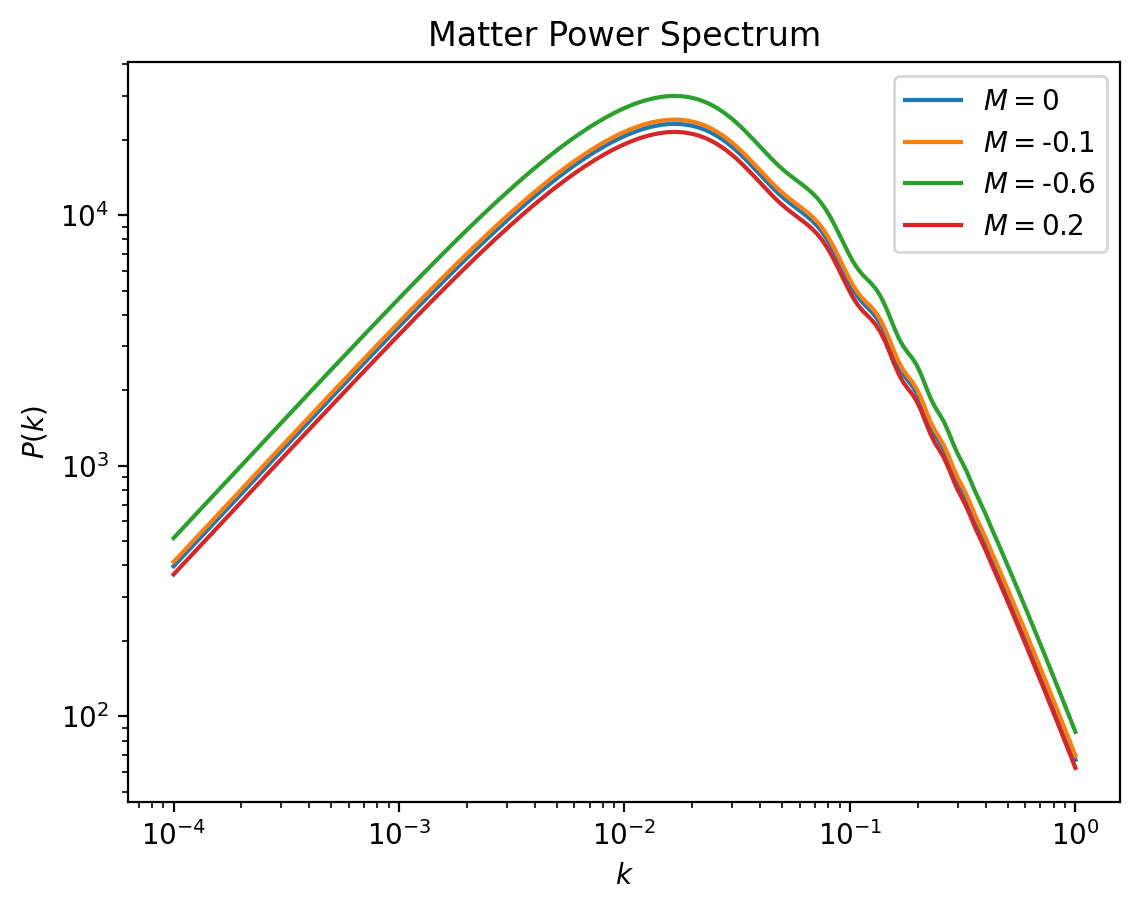

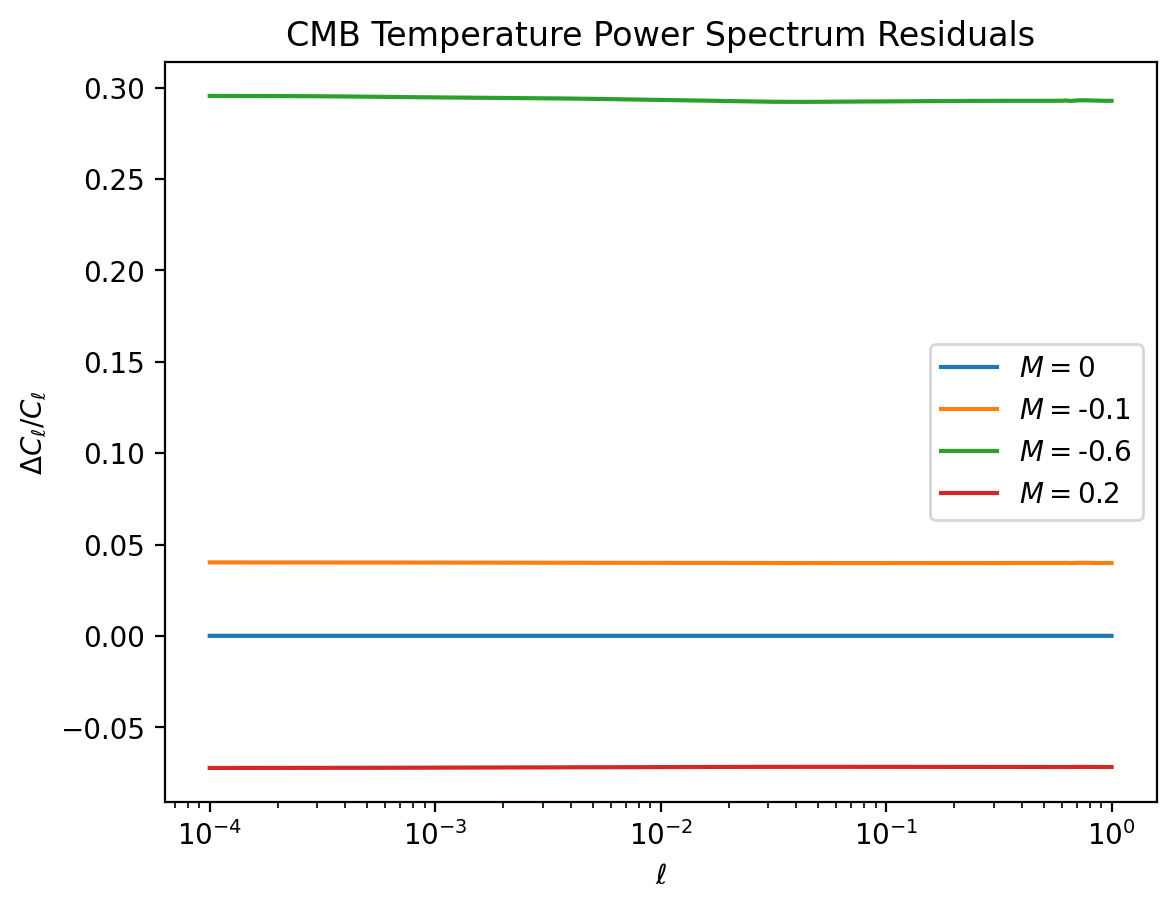

In [8]:
Ms = [0, -0.1,-0.6,0.2]
i = [0, 0.022, 1, 3]
legends = [r'$M = $'+ str(x) for x in Ms]
for M in Ms:
    
    gpncosmology=camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,M=M,
                       As=2e-9, ns=0.965, halofit_version='mead', WantTransfer=True)
    gpnresults = camb.get_results(gpncosmology)
    gpncls = gpnresults.get_unlensed_scalar_cls(CMB_unit = 'muK')[:,0]
    gpnks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[0]
    gpnpks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[2]
    gpnpowers =gpnresults.get_cmb_power_spectra(gpncosmology, CMB_unit='muK')
    plt.plot(gpnks, gpnpks[0,:])

plt.xscale('log')
plt.yscale('log')
plt.title('Matter Power Spectrum')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.legend(legends)
plt.show()

Ms = [0, -0.1,-0.6,0.2]
legends = [r'$M = $'+ str(x) for x in Ms]
for M in Ms:
    
    gpncosmology=camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,M=M,
                       As=2e-9, ns=0.965, halofit_version='mead', WantTransfer=True)
    gpnresults = camb.get_results(gpncosmology)
    gpncls = gpnresults.get_unlensed_scalar_cls(CMB_unit = 'muK')[:,0]
    gpnks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[0]
    gpnpks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[2]
    gpnpowers =gpnresults.get_cmb_power_spectra(gpncosmology, CMB_unit='muK')
    plt.plot(gpnks, (gpnpks[0,:] - lcdmpks[0,:])/lcdmpks[0,:])

plt.xscale('log')
plt.title('CMB Temperature Power Spectrum Residuals')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\Delta C_\ell / C_\ell$')
plt.legend(legends)
plt.show()
